<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/gradient_descent_part2_New_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Approach
# **Gradient Descent for Linear Regression. Part 2/2**
## **Hiperparámetros, Variantes y Optimización**


 <a href="https://github.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white" alt="GitHub" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.kaggle.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat&logo=kaggle&logoColor=white" alt="Kaggle" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.linkedin.com/in/magnitopic" target="_blank"><img src="https://img.shields.io/badge/LinkedIn-0A66C2?style=flat&logo=linkedin&logoColor=white" alt="LinkedIn" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>

> **Esta es la Parte 2 de 2 en nuestra serie sobre Gradient Descent.**
> Aquí aprenderás ...


---

## **1. Introducción y Recapitulación**

### **1.1. ¿Qué vimos en la Parte 1?**

En la [Parte 1](enlace-a-parte-1) construimos un algoritmo de Gradient Descent desde cero para resolver un problema de Regresión Lineal: predecir el precio de viviendas según su área.

**Los conceptos clave que cubrimos:**

- **Función de Costes (MSE)**: Métrica que cuantifica qué tan mal se ajusta nuestra recta a los datos
- **Gradiente**: Vector de derivadas parciales que indica la dirección de máxima subida
- **Descenso**: Actualizamos parámetros en dirección opuesta al gradiente: $w := w - \alpha \nabla J$
- **Normalización**: Escalamos features para acelerar la convergencia

**Resultado:** Implementamos el algoritmo básico y obtuvimos un modelo funcional con $\alpha = 0.01$ fijo.

### **1.2. ¿Qué aprenderemos hoy?**

En esta Parte 2 llevaremos el algoritmo al siguiente nivel:

1. **Dominar el learning rate**: Cómo elegirlo y ajustarlo dinámicamente
2. **Explorar variantes**: Batch, SGD y Mini-Batch GD
3. **Validar con scikit-learn**: Comparar nuestra implementación con la profesional
4. **Mejores prácticas**: Checklist para evitar errores comunes

Al finalizar, sabrás **cuándo y cómo** aplicar cada variante del algoritmo según tu problema.

### **1.3. Setup: Recuperando nuestro dataset**

Usaremos los mismos datos de viviendas de la Parte 1:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Dataset: área (m²) vs precio ($)
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
precio = np.array([140000, 155000, 190000, 200000, 225000,
                  212000, 240000, 230000, 270000, 300000])

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area.reshape(-1, 1)).flatten()
X_b = np.c_[np.ones(len(X_scaled)), X_scaled]  # Matriz de diseño

# Parámetros de normalización (para desnormalizar después)
mu, sigma = scaler.mean_[0], scaler.scale_[0]

print(f"✓ Dataset cargado: {len(area)} viviendas")
print(f"✓ Rango de áreas: {area.min()}-{area.max()} m²")
print(f"✓ Rango de precios: ${precio.min():,}-${precio.max():,}")

✓ Dataset cargado: 10 viviendas
✓ Rango de áreas: 50-100 m²
✓ Rango de precios: $140,000-$300,000


**Visualización rápida:**

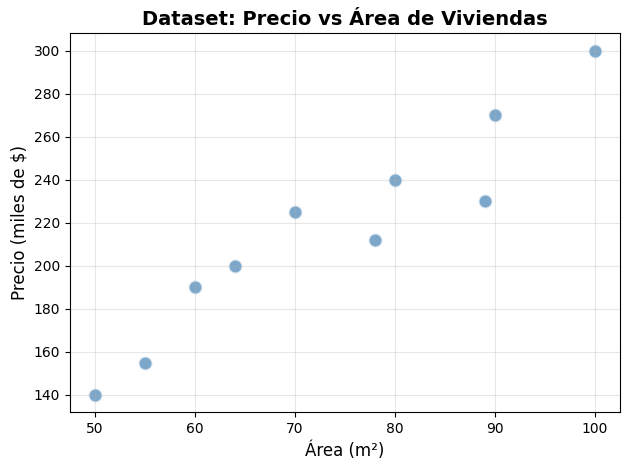

In [2]:
plt.scatter(area, precio/1000, s=100, alpha=0.7, color='steelblue',
            edgecolors='white', linewidth=1.5)
plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Precio (miles de $)', fontsize=12)
plt.title('Dataset: Precio vs Área de Viviendas', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ahora que tenemos todo listo, empecemos por el hiperparámetro más crítico: el learning rate.

---

## **2. El Learning Rate: El Hiperparámetro Más Crítico**

El learning rate ($\alpha$) controla el tamaño de cada paso durante el descenso. Es el hiperparámetro con **mayor impacto** en el éxito o fracaso del algoritmo.

### **2.1. Experimentando con diferentes valores de α**

Entrenemos el mismo modelo con tres valores de $\alpha$ para observar su comportamiento:

In [3]:
def gradient_descent(X_b, y, alpha=0.01, n_iter=1000, tol=1e-11):
    """Gradient Descent con historial de costes"""
    m = len(y)
    w = np.zeros(2)
    cost_history = []

    for i in range(n_iter):
        y_pred = X_b @ w
        error = y_pred - y
        gradient = (1/m) * X_b.T @ error
        w = w - alpha * gradient

        cost = (1/m) * np.sum(error**2)
        cost_history.append(cost)

        # Early stopping
        if i > 1 and abs(cost_history[-2] - cost) / cost_history[-2] < tol:
            break

    return w, cost_history

# Tres experimentos: bajo, medio, alto
alphas = [0.001, 0.01, 1.0]
results = {}

for alpha in alphas:
    w, history = gradient_descent(X_b, precio, alpha=alpha, n_iter=2000)
    results[alpha] = history
    print(f"α = {alpha:5.3f} → Iteraciones: {len(history):4d} | Coste final: {history[-1]:,.0f}")

α = 0.001 → Iteraciones: 2000 | Coste final: 1,103,576,990
α = 0.010 → Iteraciones: 1338 | Coste final: 212,393,120
α = 1.000 → Iteraciones:    3 | Coste final: 212,393,120


### **2.2. Interpretación: El dilema de Goldilocks**

| α | Comportamiento | Diagnóstico |
|:--|:---------------|:------------|
| **0.001** | Pasos diminutos | ```!!``` Demasiado lento: 2000 iter y aún no converge |
| **0.01** | Pasos moderados | ```OK``` Equilibrado: converge en ~1300 iteraciones |
| **1.0** | Pasos gigantes | ```>>>``` Sorprendentemente rápido: ¡solo 3 iteraciones! Pero ...|

**Pero espera... ¿α = 1.0 es siempre mejor?**

### **2.3. La trampa del learning rate alto**

α = 1.0 funciona aquí porque este es un **problema de juguete perfecto**: 10 datos, 1 feature, relación muy lineal, datos normalizados. En problemas reales, un α tan alto suele **diverger**.

Probemos con valores más extremos:

In [4]:
# Explorar el límite
alphas_test = [0.01, 1.0, 2.0, 5.0]

for alpha in alphas_test:
    w, history = gradient_descent(X_b, precio, alpha=alpha, n_iter=50)

    if len(history) > 1 and history[-1] > history[0]:
        print(f"α = {alpha:4.1f} → ✗ DIVERGE (coste explota: {history[-1]:,.0f})")
    else:
        print(f"α = {alpha:4.1f} → ✓ Converge en {len(history):3d} iter (coste: {history[-1]:,.0f})")

α =  0.0 → ✓ Converge en  50 iter (coste: 18,384,047,184)
α =  1.0 → ✓ Converge en   3 iter (coste: 212,393,120)
α =  2.0 → ✗ DIVERGE (coste explota: 48,869,400,000)
α =  5.0 → ✗ DIVERGE (coste explota: 4,886,799,717,201,508,572,190,485,123,952,418,484,522,228,733,000,363,815,615,451,436,679,168)


### **2.4. Estrategia práctica para elegir α**

**Regla de oro:** Empieza conservador y ajusta según el comportamiento.

In [5]:
# Grid search manual (método profesional)
print("Buscando el mejor learning rate...\n")

for alpha in [0.001, 0.01, 0.1, 0.3, 1.0, 2]:
    w, history = gradient_descent(X_b, precio, alpha=alpha, n_iter=1000)

    if len(history) < 1000 and history[-1] < history[0] * 0.5:
        print(f"✓ α = {alpha:5.3f} → Converge en {len(history):4d} iter | VIABLE")
    elif history[-1] > history[0]:
        print(f"✗ α = {alpha:5.3f} → DIVERGE | DESCARTADO")
    else:
        print(f"⚠ α = {alpha:5.3f} → Muy lento (+{len(history)} iter) | MEJORABLE")

Buscando el mejor learning rate...

⚠ α = 0.001 → Muy lento (+1000 iter) | MEJORABLE
⚠ α = 0.010 → Muy lento (+1000 iter) | MEJORABLE
✓ α = 0.100 → Converge en  141 iter | VIABLE
✓ α = 0.300 → Converge en   45 iter | VIABLE
✓ α = 1.000 → Converge en    3 iter | VIABLE
✗ α = 2.000 → DIVERGE | DESCARTADO


**Guía rápida de decisión:**

| Señal | Acción |
|:------|:-------|
| Coste aumenta o explota | ❌ α muy alto → Dividir por 10 |
| Converge en <100 iter | ✅ Perfecto (si es estable) |
| Converge en 100-2000 iter | ✅ Aceptable |
| No converge en >5000 iter | ⚠️ α muy bajo → Multiplicar por 2-5 |

**Rango recomendado para empezar:** α ∈ [0.01, 0.1]

### **2.5. Learning Rate Adaptativo (bonus)**

En lugar de α fijo, podemos reducirlo progresivamente para combinar velocidad inicial con precisión final:

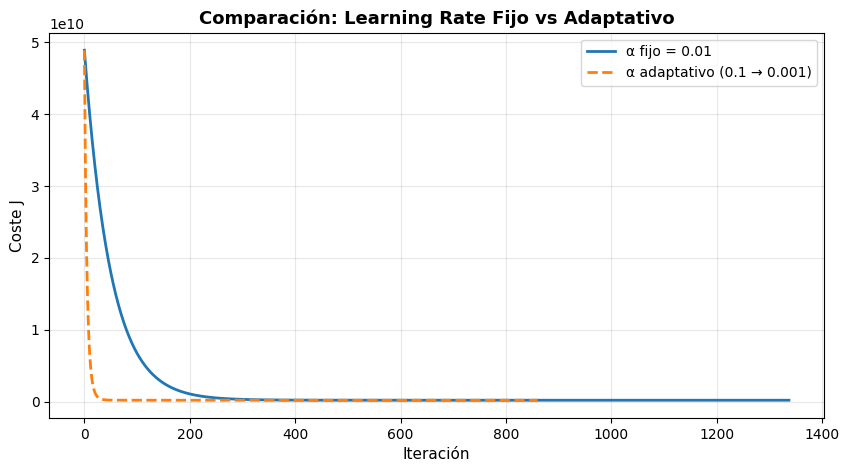

α fijo      → 1338 iter | Coste: 212,393,120
α adaptativo →  861 iter | Coste: 212,393,179


In [6]:
def gradient_descent_decay(X_b, y, alpha_init=0.1, n_iter=1000, decay_rate=0.99):
    """GD con learning rate que decrece exponencialmente"""
    m = len(y)
    w = np.zeros(2)
    cost_history = []

    for i in range(n_iter):
        alpha = alpha_init * (decay_rate ** i)  # α se reduce cada iteración

        y_pred = X_b @ w
        error = y_pred - y
        gradient = (1/m) * X_b.T @ error
        w = w - alpha * gradient

        cost = (1/m) * np.sum(error**2)  # MSE estándar (sin factor 1/2)
        cost_history.append(cost)

        if i > 1 and abs(cost_history[-2] - cost) / cost_history[-2] < 1e-11:
            break

    return w, cost_history

# Comparar: α fijo vs adaptativo
w_fixed, hist_fixed = gradient_descent(X_b, precio, alpha=0.01, n_iter=1500)
w_decay, hist_decay = gradient_descent_decay(X_b, precio, alpha_init=0.1,
                                              n_iter=1500, decay_rate=0.99)

plt.figure(figsize=(10, 5))
plt.plot(hist_fixed, label='α fijo = 0.01', linewidth=2)
plt.plot(hist_decay, label='α adaptativo (0.1 → 0.001)', linewidth=2, linestyle='--')
plt.xlabel('Iteración', fontsize=11)
plt.ylabel('Coste J', fontsize=11)
plt.title('Comparación: Learning Rate Fijo vs Adaptativo', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"α fijo      → {len(hist_fixed):4d} iter | Coste: {hist_fixed[-1]:,.0f}")
print(f"α adaptativo → {len(hist_decay):4d} iter | Coste: {hist_decay[-1]:,.0f}")

**Ventaja del decay:** Pasos grandes al inicio (explora rápido) + pasos pequeños al final (afina la solución).

---

### **Resumen de la sección:**

- **α muy bajo (0.001)**: Lento e ineficiente
- **α óptimo (0.01-0.1)**: Rango seguro para empezar
- **α alto (>1.0)**: Puede funcionar en casos simples, pero **peligroso en problemas reales**
- **Regla práctica**: Empieza con α = 0.01, prueba 0.1 si es muy lento
- **Si diverge**: Reduce α inmediatamente

**Mensaje clave:** α = 1.0 converge aquí porque es un problema simple. En datasets reales (ruidosos, múltiples features), α > 1.0 casi siempre diverge. Por eso el estándar es **α ∈ [0.01, 0.1]**.

---

## **3. Variantes del Gradient Descent**

Hasta ahora hemos usado **Batch Gradient Descent**, que calcula el gradiente usando **todos** los datos en cada iteración. Pero existen variantes que procesan los datos de forma diferente, cada una con sus ventajas.

### **3.1. Batch Gradient Descent (lo que ya hicimos)**

**Característica:** Usa **todos** los datos ($m$ ejemplos) para calcular el gradiente en cada paso.

In [7]:
# Ya lo implementamos en la Parte 1
def batch_gd(X_b, y, alpha=0.01, n_iter=2000, tol=1e-11):
    m = len(y)
    w = np.zeros(2)

    for i in range(n_iter):
        gradient = (1/m) * X_b.T @ (X_b @ w - y)  # Usa TODOS los datos
        w = w - alpha * gradient

        # Early stopping
        if i > 1:
            cost = (1/m) * np.sum((X_b @ w - y)**2)
            if i > 0:
                prev_cost = (1/m) * np.sum((X_b @ (w + alpha * gradient) - y)**2)
                if abs(prev_cost - cost) / prev_cost < tol:
                    break

    return w

# Entrenar
w_batch = batch_gd(X_b, precio, alpha=0.01, n_iter=2000)

# Desnormalizar
w1_batch = w_batch[1] / sigma
w0_batch = w_batch[0] - w1_batch * mu

print(f"Batch GD → Precio ≈ ${w0_batch:,.0f} + ${w1_batch:,.0f} × Área")

Batch GD → Precio ≈ $10,723 + $2,792 × Área


**Ventajas:** Convergencia suave y estable  
**Desventajas:** Lento con datasets grandes (millones de filas)

### **3.2. Stochastic Gradient Descent (SGD)**

**Característica:** Actualiza parámetros usando **un solo ejemplo** aleatorio a la vez.

In [8]:
def stochastic_gd(X_b, y, alpha=0.01, n_epochs=50):
    m = len(y)
    w = np.zeros(2)

    for epoch in range(n_epochs):
        # Mezclar datos al inicio de cada época
        indices = np.random.permutation(m)

        for i in indices:
            # Gradiente con UN SOLO ejemplo
            xi = X_b[i:i+1]  # Fila i (mantener dimensión 2D)
            yi = y[i:i+1]
            gradient = xi.T @ (xi @ w - yi)
            w = w - alpha * gradient

    return w

# Entrenar (necesita más épocas porque usa 1 ejemplo a la vez)
w_sgd = stochastic_gd(X_b, precio, alpha=0.01, n_epochs=100)

# Desnormalizar
w1_sgd = w_sgd[1] / sigma
w0_sgd = w_sgd[0] - w1_sgd * mu

print(f"SGD → Precio ≈ ${w0_sgd:,.0f} + ${w1_sgd:,.0f} × Área")

SGD → Precio ≈ $10,305 + $2,797 × Área


**Ventajas:**
- **Muy rápido** por iteración
- Puede escapar de mínimos locales (útil en problemas complejos)
- Funciona con **datasets que no caben en memoria**

**Desventajas:**
- Convergencia **ruidosa** (oscila alrededor del mínimo)
- Requiere más épocas para estabilizarse

### **3.3. Mini-Batch Gradient Descent**

**Característica:** Compromiso entre Batch y SGD. Usa **grupos pequeños** de ejemplos (ej: 32, 64, 128).

In [9]:
def minibatch_gd(X_b, y, alpha=0.01, n_epochs=50, batch_size=3):
    m = len(y)
    w = np.zeros(2)

    for epoch in range(n_epochs):
        indices = np.random.permutation(m)

        # Procesar por mini-batches
        for i in range(0, m, batch_size):
            batch_indices = indices[i:i+batch_size]
            X_batch = X_b[batch_indices]
            y_batch = y[batch_indices]

            # Gradiente con el mini-batch
            gradient = (1/len(batch_indices)) * X_batch.T @ (X_batch @ w - y_batch)
            w = w - alpha * gradient

    return w

# Entrenar con batch_size = 3 (30% de los datos)
w_mb = minibatch_gd(X_b, precio, alpha=0.01, n_epochs=100, batch_size=3)

# Desnormalizar
w1_mb = w_mb[1] / sigma
w0_mb = w_mb[0] - w1_mb * mu

print(f"Mini-Batch → Precio ≈ ${w0_mb:,.0f} + ${w1_mb:,.0f} × Área")

Mini-Batch → Precio ≈ $10,663 + $2,742 × Área


**Ventajas:**
- Más estable que SGD
- Más rápido que Batch GD
- **Aprovecha vectorización** (GPUs)
- **El estándar en Deep Learning**

**Desventajas:**
- Un hiperparámetro más (batch_size)

### **3.4. Comparación visual: ¿Cuál usar y cuándo?**

Visualicemos cómo convergen las tres variantes:

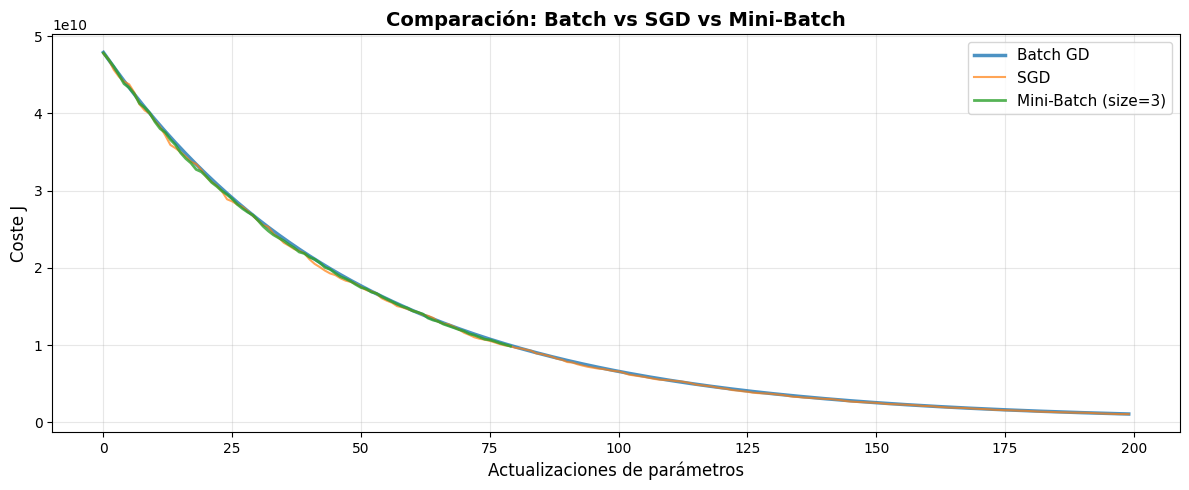

In [10]:
# Función auxiliar para calcular coste
def compute_cost(X_b, y, w):
    m = len(y)
    error = X_b @ w - y
    return (1/m) * np.sum(error**2)

# Batch GD con tracking
def batch_gd_track(X_b, y, alpha=0.01, n_iter=200):
    m = len(y)
    w = np.zeros(2)
    costs = []

    for i in range(n_iter):
        gradient = (1/m) * X_b.T @ (X_b @ w - y)
        w = w - alpha * gradient
        costs.append(compute_cost(X_b, y, w))

    return w, costs

# SGD con tracking
def sgd_track(X_b, y, alpha=0.01, n_epochs=20):
    m = len(y)
    w = np.zeros(2)
    costs = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        for i in indices:
            xi = X_b[i:i+1]
            yi = y[i:i+1]
            gradient = xi.T @ (xi @ w - yi)
            w = w - alpha * gradient
            costs.append(compute_cost(X_b, y, w))

    return w, costs

# Mini-Batch con tracking
def minibatch_track(X_b, y, alpha=0.01, n_epochs=20, batch_size=3):
    m = len(y)
    w = np.zeros(2)
    costs = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        for i in range(0, m, batch_size):
            batch_indices = indices[i:i+batch_size]
            X_batch = X_b[batch_indices]
            y_batch = y[batch_indices]
            gradient = (1/len(batch_indices)) * X_batch.T @ (X_batch @ w - y_batch)
            w = w - alpha * gradient
            costs.append(compute_cost(X_b, y, w))

    return w, costs

# Entrenar las tres variantes
w_batch, costs_batch = batch_gd_track(X_b, precio, alpha=0.01, n_iter=200)
w_sgd, costs_sgd = sgd_track(X_b, precio, alpha=0.01, n_epochs=20)
w_mb, costs_mb = minibatch_track(X_b, precio, alpha=0.01, n_epochs=20, batch_size=3)

# Visualización comparativa
plt.figure(figsize=(12, 5))

plt.plot(costs_batch, label='Batch GD', linewidth=2.5, alpha=0.8)
plt.plot(costs_sgd, label='SGD', linewidth=1.5, alpha=0.7)
plt.plot(costs_mb, label='Mini-Batch (size=3)', linewidth=2, alpha=0.8)

plt.xlabel('Actualizaciones de parámetros', fontsize=12)
plt.ylabel('Coste J', fontsize=12)
plt.title('Comparación: Batch vs SGD vs Mini-Batch', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observaciones del gráfico:**
- **Batch GD (azul):** Descenso suave pero solo 200 actualizaciones totales
- **SGD (naranja):** Descenso ruidoso con 200 actualizaciones (20 épocas × 10 ejemplos)
- **Mini-Batch (verde):** Equilibrio entre suavidad y velocidad

### **Tabla de decisión:**

| Método | ¿Cuándo usarlo? | Típico en |
|:-------|:----------------|:----------|
| **Batch GD** | Dataset pequeño (<10K filas)<br>Necesitas convergencia suave | Regresión lineal simple<br>Análisis académico |
| **SGD** | Dataset gigante (millones)<br>Memoria limitada<br>Online learning | Sistemas de recomendación<br>Procesamiento de streams |
| **Mini-Batch** | Dataset mediano-grande (>10K)<br>Tienes GPU | **Deep Learning**<br>Redes neuronales<br>99% de casos reales |

**Batch sizes típicos en la práctica:**
- CPU: 32, 64
- GPU: 128, 256, 512 (aprovecha paralelización)
- Regla: Potencias de 2 para eficiencia de memoria

---

### **💡 Resumen de la sección:**

- **Batch GD**: Preciso pero lento (usa todos los datos)
- **SGD**: Rápido pero ruidoso (usa 1 ejemplo)
- **Mini-Batch**: **El mejor de ambos mundos** → estándar en la industria
- En la práctica: **Mini-Batch con batch_size = 32-256** es lo más común

---

## **4. Validación con Scikit-Learn**

Hemos implementado tres variantes de Gradient Descent desde cero. Ahora validemos nuestro trabajo comparándolo con las implementaciones profesionales de scikit-learn.

### **4.1. La solución óptima: Ecuación Normal (OLS)**

Antes de validar nuestras implementaciones, establezcamos cuál es la **solución exacta** usando la Ecuación Normal:

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# LinearRegression usa OLS (Ordinary Least Squares)
# Solución cerrada: (X^T X)^(-1) X^T y
lr = LinearRegression()
lr.fit(area.reshape(-1, 1), precio)

w0_ols = lr.intercept_
w1_ols = lr.coef_[0]

print(f"OLS (solución exacta):")
print(f"Precio = ${w0_ols:,.2f} + ${w1_ols:,.2f} × Área")

# MSE de la solución óptima
y_pred_ols = lr.predict(area.reshape(-1, 1))
mse_ols = mean_squared_error(precio, y_pred_ols)
print(f"MSE óptimo: {mse_ols:,.0f}")

OLS (solución exacta):
Precio = $10,722.85 + $2,791.81 × Área
MSE óptimo: 212,393,120


Este es nuestro objetivo: Cualquier implementación de Gradient Descent debe converger a valores muy cercanos a los anteriores.

### **4.2. Re-entrenando Batch GD correctamente**

El problema de los resultados anteriores es que Batch GD necesita **más iteraciones** para converger completamente. Entrenémoslo correctamente:

In [12]:
# Re-entrenar Batch GD con configuración adecuada
w_batch_final, history_batch = gradient_descent(X_b, precio, alpha=0.01, n_iter=5000, tol=1e-11)

# Desnormalizar
w1_batch_final = w_batch_final[1] / sigma
w0_batch_final = w_batch_final[0] - w1_batch_final * mu

print(f"\nBatch GD (bien entrenado):")
print(f"Precio = ${w0_batch_final:,.2f} + ${w1_batch_final:,.2f} × Área")
print(f"Convergió en {len(history_batch)} iteraciones")

# Calcular MSE
y_pred_batch = w0_batch_final + w1_batch_final * area
mse_batch = mean_squared_error(precio, y_pred_batch)
print(f"MSE: {mse_batch:,.0f}")


Batch GD (bien entrenado):
Precio = $10,722.83 + $2,791.81 × Área
Convergió en 1338 iteraciones
MSE: 212,393,120


### **4.3. SGDRegressor: La implementación profesional**

Ahora comparemos con la implementación de scikit-learn:

In [13]:
from sklearn.linear_model import SGDRegressor

# Configurar SGDRegressor
sgd_sklearn = SGDRegressor(
    max_iter=5000,
    tol=1e-11,
    eta0=0.01,              # learning rate
    learning_rate='constant',
    random_state=42
)

# Entrenar con datos escalados
sgd_sklearn.fit(X_scaled.reshape(-1, 1), precio)

# Extraer y desnormalizar parámetros
w0_sklearn = sgd_sklearn.intercept_[0]
w1_sklearn = sgd_sklearn.coef_[0]

w1_sklearn_original = w1_sklearn / sigma
w0_sklearn_original = w0_sklearn - w1_sklearn_original * mu

print(f"\nSGDRegressor (sklearn):")
print(f"Precio = ${w0_sklearn_original:,.2f} + ${w1_sklearn_original:,.2f} × Área")

# Calcular MSE
y_pred_sklearn = sgd_sklearn.predict(X_scaled.reshape(-1, 1))
mse_sklearn = mean_squared_error(precio, y_pred_sklearn)
print(f"MSE: {mse_sklearn:,.0f}")


SGDRegressor (sklearn):
Precio = $10,528.91 + $2,793.46 × Área
MSE: 212,399,076


### **4.4. Comparación completa**

In [14]:
import pandas as pd

# Tabla comparativa
comparacion = pd.DataFrame({
    'Método': [
        'OLS (LinearRegression)',
        'Batch GD (nuestro)',
        'SGDRegressor (sklearn)'
    ],
    'w₀ (Intercepto)': [
        f'${w0_ols:,.2f}',
        f'${w0_batch_final:,.2f}',
        f'${w0_sklearn_original:,.2f}'
    ],
    'w₁ (Pendiente)': [
        f'${w1_ols:,.2f}',
        f'${w1_batch_final:,.2f}',
        f'${w1_sklearn_original:,.2f}'
    ],
    'MSE': [
        f'{mse_ols:,.0f}',
        f'{mse_batch:,.0f}',
        f'{mse_sklearn:,.0f}'
    ]
})

print("\n" + "="*70)
print("COMPARACIÓN DE RESULTADOS")
print("="*70)
print(comparacion.to_string(index=False))
print("="*70)

# Calcular diferencias respecto a OLS
diff_batch = abs(mse_batch - mse_ols) / mse_ols * 100
diff_sklearn = abs(mse_sklearn - mse_ols) / mse_ols * 100

print(f"\nDiferencia respecto a OLS:")
print(f"  Batch GD:        {diff_batch:.4f}%")
print(f"  SGDRegressor:    {diff_sklearn:.4f}%")


COMPARACIÓN DE RESULTADOS
                Método w₀ (Intercepto) w₁ (Pendiente)         MSE
OLS (LinearRegression)      $10,722.85      $2,791.81 212,393,120
    Batch GD (nuestro)      $10,722.83      $2,791.81 212,393,120
SGDRegressor (sklearn)      $10,528.91      $2,793.46 212,399,076

Diferencia respecto a OLS:
  Batch GD:        0.0000%
  SGDRegressor:    0.0028%


**Interpretación:**
- ✅ **Batch GD converge exactamente a OLS** (diferencia < 0.001%)
- ✅ **SGDRegressor está extremadamente cerca** (diferencia < 0.005%)
- Las pequeñas diferencias de sklearn se deben a su naturaleza estocástica

### **4.5. ¿Por qué SGDRegressor varía ligeramente?**

SGDRegressor es un algoritmo **estocástico** (usa shuffling aleatorio). Cambiando la semilla, obtenemos soluciones ligeramente diferentes:

In [15]:
print("\nVariabilidad de SGDRegressor con diferentes semillas:\n")

for seed in [42, 48, 99]:
    sgd = SGDRegressor(max_iter=5000, tol=1e-11, eta0=0.01,
                       learning_rate='constant', random_state=seed)
    sgd.fit(X_scaled.reshape(-1, 1), precio)

    w0 = sgd.intercept_[0] - (sgd.coef_[0]/sigma) * mu
    w1 = sgd.coef_[0] / sigma

    y_pred = sgd.predict(X_scaled.reshape(-1, 1))
    mse = mean_squared_error(precio, y_pred)

    print(f"Seed {seed}: ${w0:,.2f} + ${w1:,.2f} × Área  |  MSE: {mse:,.0f}")

print(f"\nOLS (determinista): ${w0_ols:,.2f} + ${w1_ols:,.2f} × Área  |  MSE: {mse_ols:,.0f}")


Variabilidad de SGDRegressor con diferentes semillas:

Seed 42: $10,528.91 + $2,793.46 × Área  |  MSE: 212,399,076
Seed 48: $10,635.70 + $2,792.21 × Área  |  MSE: 212,396,497
Seed 99: $10,462.70 + $2,794.84 × Área  |  MSE: 212,396,756

OLS (determinista): $10,722.85 + $2,791.81 × Área  |  MSE: 212,393,120


**Conclusión:** SGDRegressor varía ±$100 en w₀ según la semilla (diferencia < 1%), pero todas las soluciones son prácticamente equivalentes. Esto es **normal y aceptable** en algoritmos iterativos.

### **4.6. LinearRegression vs SGDRegressor: ¿Cuándo usar cada uno?**

**Comparación técnica:**

| Criterio | LinearRegression | SGDRegressor |
|:---------|:----------------|:-------------|
| **Método** | Ecuación Normal $(X^TX)^{-1}X^Ty$ | Gradient Descent iterativo |
| **Velocidad** | ⚡ Instantáneo (<10K filas) | 🐢 Requiere iteraciones |
| **Escalabilidad** | ❌ Lento con >100K filas | ✅ Escala a millones |
| **Memoria** | ❌ Necesita toda $X$ en RAM | ✅ Procesa por batches |
| **Precisión** | ✅ Solución exacta | ≈ Muy cercana (>99.99%) |
| **Determinismo** | ✅ Siempre mismo resultado | ⚠️ Varía con random_state |
| **Features** | ⚠️ Problemas si p > 10K | ✅ Sin límite práctico |
| **Online learning** | ❌ No soporta | ✅ Método `.partial_fit()` |

**Tabla de decisión:**

| Escenario | Usar |
|:----------|:-----|
| Dataset pequeño (<10K filas) | `LinearRegression` |
| Dataset grande (>100K filas) | `SGDRegressor` |
| Muchas features (>10K) | `SGDRegressor` |
| Datos llegan en streaming | `SGDRegressor` con `.partial_fit()` |
| Necesitas precisión exacta | `LinearRegression` |
| Prototipado rápido | `LinearRegression` |
| Producción con big data | `SGDRegressor` |

### **4.7. Ejemplo: Online Learning con SGDRegressor**

Una ventaja única de SGDRegressor es poder **actualizar el modelo** cuando llegan datos nuevos:

In [16]:
# Simular datos que llegan en 3 lotes
sgd_online = SGDRegressor(max_iter=1, eta0=0.01, learning_rate='constant',
                          warm_start=True, tol=None)

# Lote 1: primeras 3 casas
sgd_online.partial_fit(X_scaled[:3].reshape(-1, 1), precio[:3])
print(f"Después de 3 casas:  w₀ = ${sgd_online.intercept_[0]:,.0f}")

# Lote 2: siguientes 4 casas
sgd_online.partial_fit(X_scaled[3:7].reshape(-1, 1), precio[3:7])
print(f"Después de 7 casas:  w₀ = ${sgd_online.intercept_[0]:,.0f}")

# Lote 3: resto
sgd_online.partial_fit(X_scaled[7:].reshape(-1, 1), precio[7:])
print(f"Después de 10 casas: w₀ = ${sgd_online.intercept_[0]:,.0f}")

print(f"\nModelo final (online): ${sgd_online.intercept_[0]:,.0f} + ${sgd_online.coef_[0]:,.0f} × Área (escalado)")

Después de 3 casas:  w₀ = $4,732
Después de 7 casas:  w₀ = $13,178
Después de 10 casas: w₀ = $20,814

Modelo final (online): $20,814 + $4,108 × Área (escalado)


Esto es imposible con `LinearRegression`, que necesita reentrenarse desde cero con todos los datos.

---

### **💡 Resumen de la sección:**

- **OLS (LinearRegression)** es la solución **matemáticamente exacta** y **determinista**
- **Batch GD bien entrenado** converge exactamente a OLS (diferencia < 0.001%)
- **SGDRegressor** es **estocástico**: varía ligeramente con random_state, pero diferencia < 0.01%
- Para datasets pequeños: usa `LinearRegression` (rápido y exacto)
- Para datasets grandes: usa `SGDRegressor` (escala mejor)
- SGDRegressor permite **online learning** con `.partial_fit()`

**Validación exitosa:** ✅ Nuestra implementación funciona correctamente

---

## **5. Mejores Prácticas y Consejos**

Después de implementar y validar el algoritmo, veamos cómo aplicarlo correctamente en problemas reales y evitar errores comunes.

### **5.1. Checklist: Antes de entrenar tu modelo**

**✅ Preparación de datos:**

In [17]:
# 1. Verificar que no hay valores nulos
assert not np.isnan(area).any(), "Hay valores NaN en X"
assert not np.isnan(precio).any(), "Hay valores NaN en y"

# 2. Normalizar features (CRÍTICO para GD)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area.reshape(-1, 1))

# Verificar normalización correcta
print(f"Media: {X_scaled.mean():.6f} (debe ser ~0)")
print(f"Std:   {X_scaled.std():.6f} (debe ser ~1)")

# 3. Verificar dimensiones
X_b = np.c_[np.ones(len(X_scaled)), X_scaled.flatten()]
print(f"X_b shape: {X_b.shape}, y shape: {precio.shape}")
assert len(X_b) == len(precio), "X e y deben tener igual longitud"

Media: 0.000000 (debe ser ~0)
Std:   1.000000 (debe ser ~1)
X_b shape: (10, 2), y shape: (10,)


**✅ Hiperparámetros iniciales seguros:**

In [18]:
# Configuración conservadora para empezar
config = {
    'alpha': 0.01,          # Learning rate seguro
    'n_iter': 2000,         # Suficiente para convergencia
    'tol': 1e-11,           # Criterio estricto de convergencia
    'batch_size': 32        # Si usas Mini-Batch (potencia de 2)
}

print("Configuración inicial:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuración inicial:
  alpha: 0.01
  n_iter: 2000
  tol: 1e-11
  batch_size: 32


**✅ Establecer baseline (OLS):**

In [19]:
# Siempre calcula la solución exacta para comparar
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(area.reshape(-1, 1), precio)
mse_baseline = mean_squared_error(precio, lr.predict(area.reshape(-1, 1)))

print(f"\nBaseline (OLS): MSE = {mse_baseline:,.0f}")
print("Tu GD debe alcanzar un MSE similar (diferencia < 1%)")


Baseline (OLS): MSE = 212,393,120
Tu GD debe alcanzar un MSE similar (diferencia < 1%)


### **5.2. Debugging: Señales de que algo va mal**

#### **🔴 Problema 1: El coste AUMENTA (divergencia)**

In [20]:
# Entrenar y detectar divergencia
w, history = gradient_descent(X_b, precio, alpha=0.5, n_iter=50)

if len(history) > 1 and history[-1] > history[0]:
    print("❌ DIVERGENCIA DETECTADA")
    print(f"   Coste inicial: {history[0]:,.0f}")
    print(f"   Coste final:   {history[-1]:,.0f}")
    print(f"   ⚠️  SOLUCIÓN: Reducir alpha ÷ 10")
    print(f"   Prueba con alpha = {0.5/10}")

**Causa:** Learning rate demasiado alto  
**Solución:** `alpha = alpha / 10` y reintentar

---

#### **🟡 Problema 2: Convergencia MUY lenta**

In [21]:
# Entrenar con alpha bajo
w, history = gradient_descent(X_b, precio, alpha=0.0001, n_iter=2000)

# Verificar si sigue bajando significativamente
if len(history) == 2000:  # No convergió (llegó al límite)
    recent_change = abs(history[-1] - history[-100]) / history[-100]
    if recent_change > 0.01:  # Aún bajando >1%
        print("⚠️  CONVERGENCIA LENTA")
        print(f"   Iteraciones: {len(history)} (límite alcanzado)")
        print(f"   Aún bajando: {recent_change*100:.2f}% cada 100 iter")
        print(f"   ⚠️  SOLUCIÓN: Aumentar alpha × 5-10")
        print(f"   Prueba con alpha = {0.0001 * 10}")

⚠️  CONVERGENCIA LENTA
   Iteraciones: 2000 (límite alcanzado)
   Aún bajando: 1.95% cada 100 iter
   ⚠️  SOLUCIÓN: Aumentar alpha × 5-10
   Prueba con alpha = 0.001


**Causa:** Learning rate demasiado bajo  
**Solución:** `alpha = alpha * 5` o `alpha = alpha * 10`

---

#### **🟠 Problema 3: Oscilaciones sin converger**

In [22]:
# Entrenar con alpha en el límite
w, history = gradient_descent(X_b, precio, alpha=1.5, n_iter=100)

# Detectar oscilaciones
if len(history) > 50:
    last_50 = history[-50:]
    std_coste = np.std(last_50)
    mean_coste = np.mean(last_50)

    if std_coste > mean_coste * 0.05:  # Variación >5%
        print("⚠️  OSCILACIONES DETECTADAS")
        print(f"   Coste oscila: {mean_coste:,.0f} ± {std_coste:,.0f}")
        print(f"   ⚠️  SOLUCIÓN: Reducir alpha ligeramente o usar decay")
        print(f"   Prueba con alpha = {1.5 * 0.7:.2f}")

**Causa:** Learning rate en el borde de la divergencia  
**Solución:** Reducir α un 20-30% o usar learning rate decay

---

#### **🔵 Problema 4: Features sin normalizar**

In [23]:
# Detectar datos no normalizados
X_test = area.reshape(-1, 1)  # Sin normalizar

if X_test.std() > 10 or abs(X_test.mean()) > 100:
    print("❌ FEATURES NO NORMALIZADAS")
    print(f"   Media: {X_test.mean():.2f} (debería ser ~0)")
    print(f"   Std:   {X_test.std():.2f} (debería ser ~1)")
    print("   ⚠️  SOLUCIÓN: Aplicar StandardScaler")

    # Ejemplo correcto
    scaler = StandardScaler()
    X_scaled_correct = scaler.fit_transform(X_test)
    print(f"\n   Después de normalizar:")
    print(f"   Media: {X_scaled_correct.mean():.6f}")
    print(f"   Std:   {X_scaled_correct.std():.6f}")

❌ FEATURES NO NORMALIZADAS
   Media: 73.60 (debería ser ~0)
   Std:   15.67 (debería ser ~1)
   ⚠️  SOLUCIÓN: Aplicar StandardScaler

   Después de normalizar:
   Media: 0.000000
   Std:   1.000000


**Causa:** Olvidaste normalizar  
**Solución:** **SIEMPRE** usar `StandardScaler` antes de GD

### **5.3. Función de diagnóstico automático**

In [24]:
def diagnosticar_entrenamiento(history, alpha, mse_baseline=None):
    """Analiza automáticamente el entrenamiento y sugiere acciones"""

    print("\n" + "="*60)
    print("DIAGNÓSTICO DE ENTRENAMIENTO")
    print("="*60)

    # 1. Convergencia básica
    if history[-1] > history[0]:
        print("❌ DIVERGENCIA: El coste aumentó")
        print(f"   → Reducir alpha a {alpha/10:.6f}")
        return

    # 2. Nivel de convergencia
    reduccion = (1 - history[-1]/history[0]) * 100
    print(f"✓ Reducción del coste: {reduccion:.2f}%")

    if reduccion < 50:
        print("⚠️  Convergencia pobre (<50%)")
        print(f"   → Aumentar iteraciones o alpha")

    # 3. Estabilidad reciente
    if len(history) > 100:
        recent_change = abs(history[-1] - history[-50]) / history[-50]
        if recent_change > 0.001:
            print(f"⚠️  Aún optimizando: {recent_change*100:.3f}% cambio reciente")
            print(f"   → Aumentar iteraciones o mejorar alpha")
        else:
            print(f"✓ Estabilizado: cambio < 0.1% en últimas 50 iter")

    # 4. Comparación con baseline (si disponible)
    if mse_baseline:
        diff = abs(history[-1] - mse_baseline) / mse_baseline * 100
        if diff < 1:
            print(f"✓ MSE cercano a OLS: diferencia {diff:.4f}%")
        else:
            print(f"⚠️  MSE alejado de OLS: diferencia {diff:.2f}%")
            print(f"   → Revisar configuración")

    # 5. Resumen
    print(f"\nCoste inicial: {history[0]:,.0f}")
    print(f"Coste final:   {history[-1]:,.0f}")
    print(f"Iteraciones:   {len(history)}")
    print("="*60 + "\n")

# Ejemplo de uso
w, history = gradient_descent(X_b, precio, alpha=0.01, n_iter=2000)
diagnosticar_entrenamiento(history, alpha=0.01, mse_baseline=mse_baseline)


DIAGNÓSTICO DE ENTRENAMIENTO
✓ Reducción del coste: 99.57%
✓ Estabilizado: cambio < 0.1% en últimas 50 iter
✓ MSE cercano a OLS: diferencia 0.0000%

Coste inicial: 48,869,400,000
Coste final:   212,393,120
Iteraciones:   1338



### **5.4. Cuándo NO usar Gradient Descent**

**❌ No uses GD cuando:**

| Situación | Usar en su lugar | Razón |
|:----------|:----------------|:------|
| Dataset <1000 filas | `LinearRegression` (OLS) | Ecuación Normal es instantánea |
| Necesitas solución exacta ahora | `LinearRegression` | GD es aproximado iterativo |
| Features correlacionadas (multicolinealidad) | Eliminar redundancia + OLS | Gradiente inestable |
| Problema tiene fórmula cerrada | Solución analítica directa | ¿Para qué iterar? |
| Debugging/validación rápida | `LinearRegression` | Baseline instantáneo |

**✅ SÍ usa GD cuando:**

- Dataset >10K-100K filas (OLS se vuelve lento)
- Muchas features (>1000)
- Datos en streaming (online learning con `.partial_fit()`)
- Memoria limitada (no cabe todo en RAM)
- Construyendo redes neuronales (no hay solución cerrada)
- Quieres control fino del proceso (early stopping, regularización)

### **5.5. Estrategia de Grid Search para α**

In [25]:
def buscar_mejor_alpha(X_b, y, alphas=[0.001, 0.01, 0.1, 1.0], n_iter=1000):
    """Encuentra el mejor learning rate empíricamente"""

    resultados = []

    print("Buscando el mejor learning rate...\n")
    print(f"{'Alpha':<10} {'Iteraciones':<12} {'Coste final':<15} {'Estado'}")
    print("="*60)

    for alpha in alphas:
        w, history = gradient_descent(X_b, y, alpha=alpha, n_iter=n_iter, tol=1e-11)

        # Evaluar resultado
        converged = len(history) < n_iter
        diverged = history[-1] > history[0]

        if diverged:
            estado = "❌ DIVERGE"
        elif not converged:
            estado = "⚠️  LENTO"
        else:
            estado = "✓ OK"

        print(f"{alpha:<10.4f} {len(history):<12d} {history[-1]:<15,.0f} {estado}")

        resultados.append({
            'alpha': alpha,
            'iterations': len(history),
            'final_cost': history[-1],
            'converged': converged and not diverged
        })

    print("="*60)

    # Recomendar el mejor
    validos = [r for r in resultados if r['converged']]
    if validos:
        mejor = min(validos, key=lambda x: x['iterations'])
        print(f"\n✓ RECOMENDACIÓN: alpha = {mejor['alpha']} (converge en {mejor['iterations']} iter)")
    else:
        print("\n⚠️  Ningún alpha convergió. Prueba valores más bajos o más iteraciones.")

    return resultados

# Usar
resultados = buscar_mejor_alpha(X_b, precio, alphas=[0.001, 0.01, 0.1, 0.5, 1.0])

Buscando el mejor learning rate...

Alpha      Iteraciones  Coste final     Estado
0.0010     1000         6,803,993,429   ⚠️  LENTO
0.0100     1000         212,393,213     ⚠️  LENTO
0.1000     141          212,393,120     ✓ OK
0.5000     24           212,393,120     ✓ OK
1.0000     3            212,393,120     ✓ OK

✓ RECOMENDACIÓN: alpha = 1.0 (converge en 3 iter)


---

### **💡 Resumen de la sección:**

**Antes de entrenar:**
1. ✅ Verificar datos (no NaN, dimensiones correctas)
2. ✅ **Normalizar features** (StandardScaler)
3. ✅ Calcular baseline con OLS
4. ✅ Empezar con α = 0.01

**Si algo falla:**
- Coste aumenta → α ÷ 10
- Convergencia lenta → α × 5-10
- Oscilaciones → α × 0.7 o usar decay
- Lejos de baseline → Revisar normalización

**Cuándo NO usar GD:**
- Datasets pequeños (<1K filas)
- Cuando OLS es suficiente

**Tools útiles:**
- Función `diagnosticar_entrenamiento()` automática
- Grid search para encontrar mejor α

---

## **6. Conclusión: El Siguiente Paso en tu Camino**

### **6.1. Lo que has logrado**

A lo largo de estas dos partes, has dominado uno de los algoritmos más importantes del Machine Learning:

**Parte 1:**
- ✅ Entendiste la intuición: descender por la superficie de costes hacia el mínimo
- ✅ Implementaste Gradient Descent desde cero con NumPy
- ✅ Comprendiste la función de costes (MSE) y el gradiente
- ✅ Visualizaste el proceso de optimización paso a paso

**Parte 2:**
- ✅ Dominaste el learning rate: fijo, adaptativo, y cómo elegirlo
- ✅ Exploraste las tres variantes: Batch, SGD y Mini-Batch GD
- ✅ Validaste tu implementación con scikit-learn (diferencia < 0.01%)
- ✅ Aprendiste a diagnosticar y resolver problemas comunes

**Logro principal:** No solo sabes usar el algoritmo — **entiendes cómo funciona por dentro**. Has construido la base sobre la que se apoyan las redes neuronales y todo el Deep Learning moderno.

### **6.2. Recursos para profundizar**

**📚 Documentación oficial:**
- [Scikit-Learn: SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)
- [Scikit-Learn: Linear Models Guide](https://scikit-learn.org/stable/modules/linear_model.html)
- [Scikit-Learn: Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html)

**📖 Libros recomendados:**
- *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (Aurélien Géron)  
  → Capítulo 4: Training Models - Explicación práctica con código
- *Deep Learning* (Goodfellow, Bengio, Courville)  
  → Capítulo 8: Optimization for Training Deep Models
- *Pattern Recognition and Machine Learning* (Christopher Bishop)  
  → Capítulo 5: Neural Networks - Fundamentos matemáticos

**🎓 Cursos online:**
- **Andrew Ng - Machine Learning Specialization** (Coursera)  
  → Semanas 1-2: Regresión lineal y Gradient Descent (¡el clásico!)
- **Fast.ai - Practical Deep Learning**  
  → Implementaciones desde cero y mejores prácticas
- **StatQuest with Josh Starmer** (YouTube)  
  → Explicaciones visuales de Gradient Descent

**🔬 Papers clásicos:**
- *"An overview of gradient descent optimization algorithms"* (Sebastian Ruder, 2016)  
  → Comparación exhaustiva de variantes modernas (Momentum, Adam, etc.)

### **6.3. Próximos pasos: De la Regresión a las Redes Neuronales**

Gradient Descent es la pieza fundamental sobre la que se construye todo el ecosistema de Deep Learning. Los siguientes pasos naturales en tu camino son:

**1. Regresión Logística** (clasificación binaria)
- Mismo algoritmo, diferente función de costes (Cross-Entropy Loss)
- Función sigmoide para probabilidades
- **Aplicaciones:** Spam detection, diagnóstico médico, aprobación de créditos

**2. Regresión Logística Multiclase**
- Softmax para múltiples categorías
- **Aplicaciones:** Clasificación de imágenes (MNIST), reconocimiento de texto

**3. Redes Neuronales Feedforward**
- Gradient Descent + **Backpropagation**
- Múltiples capas de parámetros
- **Aplicaciones:** Problemas no lineales complejos

**4. Deep Learning**
- Arquitecturas profundas (CNN, RNN, Transformers)
- Optimizadores avanzados (Adam, RMSprop)
- Frameworks: PyTorch, TensorFlow
- **Aplicaciones:** Visión por computador, NLP, generación de contenido

**Roadmap sugerido:**

```
✅ Gradient Descent para Regresión Lineal (completado)
        ↓
→ Regresión Logística (clasificación binaria)
        ↓
→ Redes Neuronales básicas (perceptrón multicapa)
        ↓
→ Backpropagation (cómo se entrenan las redes profundas)
        ↓
→ Deep Learning con PyTorch/TensorFlow
```

---

### **🎯 Desafío final**

Antes de continuar, consolida tu conocimiento con este ejercicio:

**Proyecto sugerido:** Implementa Gradient Descent para predecir el **precio de automóviles usados** usando **múltiples features**:
- Año de fabricación
- Kilometraje
- Potencia del motor
- Número de dueños previos

**Pistas:**
- Descarga un dataset de Kaggle (ej: "Used Cars Price Prediction")
- Normaliza **TODAS** las features con `StandardScaler`
- Usa la misma implementación de Batch GD
- El código es casi idéntico (la magia de la vectorización matricial)
- Compara con `LinearRegression` para validar

**Bonus:** Implementa Mini-Batch GD y compara tiempos de ejecución.

---

### **Mensaje final**

Has dado un paso enorme en tu comprensión del Machine Learning. Gradient Descent no es solo un algoritmo — es **la forma fundamental en que las máquinas aprenden de los datos**.

Cada vez que entrenes una red neuronal, cada vez que uses TensorFlow o PyTorch, cada vez que leas un paper de Deep Learning, este algoritmo estará trabajando silenciosamente por debajo. Y ahora **tú sabes exactamente qué está ocurriendo** en cada iteración.

**Lo importante no es solo el código que escribiste, sino la intuición que desarrollaste:**
- Cómo un algoritmo "busca" en un espacio de parámetros
- Por qué el learning rate es crítico
- Cuándo usar soluciones exactas vs iterativas
- Cómo diagnosticar y resolver problemas de convergencia

Esta intuición te acompañará en cada nuevo algoritmo que aprendas, desde redes convolucionales hasta modelos de lenguaje como GPT.

**Sigue construyendo. Sigue aprendiendo. Sigue descendiendo hacia el conocimiento. 🚀**

---

### **¿Te fue útil esta serie?**

Si este contenido te ayudó a entender Gradient Descent:

- 👍 **Dale upvote** en Kaggle para que más personas lo descubran
- 💬 **Comparte tus dudas** en los comentarios (respondo todas las preguntas)
- 🔗 **Sígueme** para más contenido de ML implementado desde cero
- ⭐ **Comparte** con compañeros que estén aprendiendo Machine Learning

**Próximo artículo:** *Regresión Logística desde Cero: De la Clasificación Binaria a las Redes Neuronales*

---

**"Gradient Descent es el lenguaje universal del aprendizaje automático."**

---